In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are now expected on the local filesystem. Set LOCAL_DATA_DIR
# (or rely on the notebook's working directory) to point to the folder that
# contains data.csv, predict.csv, etc.

import os
from pathlib import Path

LOCAL_DATA_DIR = Path(os.environ.get("LOCAL_DATA_DIR", Path.cwd())).resolve() / "data"
print(f"LOCAL_DATA_DIR set to {LOCAL_DATA_DIR}")

LOCAL_DATA_DIR set to /home/fredc/NTU-DSAI/kaggle-lr/data


In [3]:
## Starter Code for Building Baseball Win Prediction Model

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load the pre-processed datasets from the directory pointed to by LOCAL_DATA_DIR
DATA_DIR = LOCAL_DATA_DIR  # defined in the previous cell
print(f"Loading datasets from {DATA_DIR}")

data_df = pd.read_csv(DATA_DIR / "data.csv")
predict_df = pd.read_csv(DATA_DIR / "predict.csv")

# Display basic information about the datasets
print(f"Data set shape: {data_df.shape}")
print(f"Predict set shape: {predict_df.shape}")

Loading datasets from /home/fredc/NTU-DSAI/kaggle-lr/data
Data set shape: (1812, 51)
Predict set shape: (453, 45)


In [22]:
# Add a compact set of baseball features that usually improves MAE without overcomplicating the model

def safe_divide(num, den):
    return np.where(den != 0, num / den, 0)

def get_col(df, col_name):
    if col_name in df.columns:
        return df[col_name]
    return pd.Series(0, index=df.index, dtype=float)

for df in (data_df, predict_df):
    runs = get_col(df, 'R')
    runs_allowed = get_col(df, 'RA')
    games = get_col(df, 'G')
    at_bats = get_col(df, 'AB')
    hits = get_col(df, 'H')
    doubles = get_col(df, '2B')
    triples = get_col(df, '3B')
    home_runs = get_col(df, 'HR')
    walks = get_col(df, 'BB')
    strikeouts = get_col(df, 'SO')
    steals = get_col(df, 'SB')
    caught_stealing = get_col(df, 'CS')
    hits_allowed = get_col(df, 'HA')
    walks_allowed = get_col(df, 'BBA')
    innings_outs = get_col(df, 'IPouts')

    df['run_diff'] = runs - runs_allowed
    df['run_diff_per_game'] = safe_divide(df['run_diff'], games)
    df['win_expectancy'] = safe_divide(runs ** 2, (runs ** 2) + (runs_allowed ** 2))
    df['hr_rate'] = safe_divide(home_runs, at_bats)
    df['bb_rate'] = safe_divide(walks, at_bats)
    df['so_rate'] = safe_divide(strikeouts, at_bats)
    df['hit_rate'] = safe_divide(hits, at_bats)
    df['extra_base_hits'] = doubles + triples + home_runs
    df['xbh_rate'] = safe_divide(df['extra_base_hits'], hits)
    df['steal_value'] = steals - caught_stealing
    df['baserunning_value'] = safe_divide(df['steal_value'], games)
    df['pitching_whip_proxy'] = safe_divide(hits_allowed + walks_allowed, safe_divide(innings_outs, 3))

# Select the base features plus engineered features that exist in both train and prediction data
base_features = [
    # Basic Statistics
    'G', 'R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'CS', 'HBP', 'SF',
    'RA', 'ER', 'CG', 'SHO', 'SV', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA',
    'E', 'DP', 'FP', 'attendance', 'BPF', 'PPF',

    # Derived Features already present in the dataset
    'R_per_game', 'RA_per_game', 'mlb_rpg',

    # Era Indicators
    'era_1', 'era_2', 'era_3', 'era_4', 'era_5', 'era_6', 'era_7', 'era_8',

    # Decade Indicators
    'decade_1910', 'decade_1920', 'decade_1930', 'decade_1940', 'decade_1950',
    'decade_1960', 'decade_1970', 'decade_1980', 'decade_1990', 'decade_2000', 'decade_2010'
]

engineered_features = [
    'run_diff', 'run_diff_per_game', 'win_expectancy',
    'hr_rate', 'bb_rate', 'so_rate', 'hit_rate',
    'extra_base_hits', 'xbh_rate',
    'steal_value', 'baserunning_value',
    'pitching_whip_proxy'
]

candidate_features = base_features + engineered_features
available_features = [col for col in candidate_features if col in data_df.columns and col in predict_df.columns]
print(f"Number of available features: {len(available_features)}")

# Separate features and target variable
X = data_df[available_features]
y = data_df['W']

# Perform the split (adjust test_size / random_state as needed)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Number of available features: 55


In [23]:
# Scale features
# Identify columns to exclude from scaling (one-hot encoded and label columns)
one_hot_cols = [col for col in X_train.columns if col.startswith(('era_', 'decade_'))]
other_cols = [col for col in X_train.columns if col not in one_hot_cols]

# Scale only non-one-hot features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[other_cols] = scaler.fit_transform(X_train[other_cols])
X_test_scaled[other_cols] = scaler.transform(X_test[other_cols])

In [24]:
# Build Linear Regression Model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_train_preds = lr.predict(X_train_scaled)
lr_test_preds = lr.predict(X_test_scaled)

In [38]:
# Build RidgeCV Model (v3 comparison)
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_absolute_error')
ridge_cv.fit(X_train_scaled, y_train)
print(f"RidgeCV best alpha: {ridge_cv.alpha_:.4f}")

ridge_train_preds = ridge_cv.predict(X_train_scaled)
ridge_test_preds = ridge_cv.predict(X_test_scaled)


RidgeCV best alpha: 1.0000


In [25]:
# Evaluate Linear Regression
lr_train_mae = mean_absolute_error(y_train, lr_train_preds)
lr_test_mae = mean_absolute_error(y_test, lr_test_preds)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_preds))
lr_test_r2 = r2_score(y_test, lr_test_preds)

print(f"Linear Regression Performance:")
print(f"  Training MAE: {lr_train_mae:.4f}")
print(f"  Test MAE: {lr_test_mae:.4f}")
print(f"  Test RMSE: {lr_test_rmse:.4f}")
print(f"  Test R²: {lr_test_r2:.4f}")

# Feature importance from Linear Regression
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Linear Regression Performance:
  Training MAE: 2.6107
  Test MAE: 2.8067
  Test RMSE: 3.5308
  Test R²: 0.9224

Top 10 Most Important Features:
                Feature  Coefficient
44    run_diff_per_game    -8.380704
43             run_diff     6.978370
49             hit_rate     5.957173
45       win_expectancy     5.394490
53    baserunning_value     5.388435
1                     R     5.374165
54  pitching_whip_proxy    -4.465226
47              bb_rate    -4.273759
14                   SV     4.116003
15               IPouts     3.987896


In [39]:
# Evaluate RidgeCV & Compare against Linear Regression (v3)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge_train_mae  = mean_absolute_error(y_train, ridge_train_preds)
ridge_test_mae   = mean_absolute_error(y_test,  ridge_test_preds)
ridge_test_rmse  = np.sqrt(mean_squared_error(y_test, ridge_test_preds))
ridge_test_r2    = r2_score(y_test, ridge_test_preds)

comparison = pd.DataFrame({
    'Model':       ['LinearRegression', f'RidgeCV (α={ridge_cv.alpha_:.1f})'],
    'Train MAE':   [lr_train_mae,  ridge_train_mae],
    'Test MAE':    [lr_test_mae,   ridge_test_mae],
    'Test RMSE':   [lr_test_rmse,  ridge_test_rmse],
    'Test R²':     [lr_test_r2,    ridge_test_r2],
})
comparison = comparison.set_index('Model')
print(comparison.to_string())
print(f"\nRidgeCV vs LR  |  ΔMAE (test): {ridge_test_mae - lr_test_mae:+.4f}  |  ΔR²: {ridge_test_r2 - lr_test_r2:+.4f}")


                  Train MAE  Test MAE  Test RMSE   Test R²
Model                                                     
LinearRegression   2.610700  2.806745   3.530750  0.922361
RidgeCV (α=1.0)    2.615483  2.798903   3.523498  0.922679

RidgeCV vs LR  |  ΔMAE (test): -0.0078  |  ΔR²: +0.0003


In [40]:
# Model Registry & Submission Pipeline (Future-Proof v3)
import os
from datetime import datetime

# Model registry: central place to manage all models and their metadata
models_config = {
    'LinearRegression': {
        'model': lr,
        'test_mae': lr_test_mae,
        'test_r2': lr_test_r2,
        'version': 'baseline',
    },
    'RidgeCV': {
        'model': ridge_cv,
        'test_mae': ridge_test_mae,
        'test_r2': ridge_test_r2,
        'alpha': ridge_cv.alpha_,
        'version': 'v3_regularized',
    },
}

def submit_model(model_name, submission_message=None, submit_to_kaggle=False):
    """
    Generalized submission pipeline for any registered model.
    
    Args:
        model_name (str): Key from models_config
        submission_message (str): Custom message for submission
        submit_to_kaggle (bool): Whether to actually submit to Kaggle API
    
    Returns:
        str: Path to saved submission CSV
    """
    if model_name not in models_config:
        raise ValueError(f"Model '{model_name}' not in registry. Available: {list(models_config.keys())}")
    
    config = models_config[model_name]
    model = config['model']
    
    # Prepare and scale prediction features
    predict_features = predict_df[available_features].copy()
    predict_scaled = predict_features.copy()
    predict_scaled[other_cols] = scaler.transform(predict_features[other_cols])
    
    # Generate predictions
    predictions = model.predict(predict_scaled)
    
    # Create submission dataframe
    submission_data = pd.DataFrame({
        'ID': predict_df['ID'],
        'W': predictions
    })
    
    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"submission_{model_name}_{timestamp}.csv"
    submission_data.to_csv(filename, index=False)
    
    print(f"✓ Submission saved: {filename}")
    print(f"  Model: {model_name} | Test MAE: {config['test_mae']:.4f} | Test R²: {config['test_r2']:.4f}")
    
    # Optional Kaggle submission
    if submit_to_kaggle:
        msg = submission_message or f"{model_name} - {config['version']}"
        COMPETITION_NAME = "sctpdsai-m-3-ds-2-f-coaching-money-ball-analytics"
        cmd = f'kaggle competitions submit -c {COMPETITION_NAME} -f "{filename}" -m "{msg}"'
        try:
            os.system(cmd)
            print(f"✓ Submitted to Kaggle with message: {msg}")
        except Exception as e:
            print(f"✗ Kaggle submission failed: {e}")
    
    return filename

print("Model registry initialized with:")
for name, config in models_config.items():
    print(f"  • {name}: MAE={config['test_mae']:.4f}, R²={config['test_r2']:.4f}")


Model registry initialized with:
  • LinearRegression: MAE=2.8067, R²=0.9224
  • RidgeCV: MAE=2.7989, R²=0.9227


In [41]:
# Generate Submissions for All Models
# Leverage the model registry to prepare submissions without code duplication

print("Generating submissions for all models...\n")

# Generate submission for LinearRegression
lr_submission_file = submit_model('LinearRegression', submission_message="Baseline LinearRegression model")

print()

# Generate submission for RidgeCV
ridge_submission_file = submit_model('RidgeCV', submission_message=f"RidgeCV with alpha={ridge_cv.alpha_:.1f} tuning (v3)")

print("\n✓ All submissions ready. Choose which to deploy in the next cell.")


Generating submissions for all models...

✓ Submission saved: submission_LinearRegression_20260327_172526.csv
  Model: LinearRegression | Test MAE: 2.8067 | Test R²: 0.9224

✓ Submission saved: submission_RidgeCV_20260327_172526.csv
  Model: RidgeCV | Test MAE: 2.7989 | Test R²: 0.9227

✓ All submissions ready. Choose which to deploy in the next cell.


In [48]:
# Deploy Selected Model to Kaggle
# Uncomment the model you want to submit - makes it easy to switch between variants

COMPETITION_NAME = "sctpdsai-m-3-ds-2-f-coaching-money-ball-analytics"

# === CHOOSE ONE: ===
# Option A: Deploy LinearRegression (baseline)
# selected_model = 'LinearRegression'
# selected_file = lr_submission_file

# Option B: Deploy RidgeCV (v3 with alpha tuning)
selected_model = 'RidgeCV'
selected_file = ridge_submission_file

print(f"\nSubmitting {selected_model} to Kaggle...")
print(f"File: {selected_file}\n")
submit_cmd = f'kaggle competitions submit -c {COMPETITION_NAME} -f "{selected_file}" -m "Deployment: {selected_model}"'
os.system(submit_cmd)



Submitting RidgeCV to Kaggle...
File: submission_RidgeCV_20260327_172526.csv



100%|██████████| 9.94k/9.94k [00:00<00:00, 11.5kB/s]


Successfully submitted to SCTPDSAI-M3-DS2F-Coaching-MoneyBall Analytics

0

In [50]:
# List Recent Submissions & Verify Deployment
print(f"Recent submissions for {COMPETITION_NAME}:\n")
os.system(f'kaggle competitions submissions -c {COMPETITION_NAME} | head -15')


Recent submissions for sctpdsai-m-3-ds-2-f-coaching-money-ball-analytics:

fileName                                         date                        description                   status                     publicScore  privateScore  
-----------------------------------------------  --------------------------  ----------------------------  -------------------------  -----------  ------------  
submission_RidgeCV_20260327_172526.csv           2026-03-27 09:32:17.923000  Deployment: RidgeCV           SubmissionStatus.COMPLETE  3.04701                    
submission_LinearRegression_20260327_172526.csv  2026-03-27 09:27:39.850000  Deployment: LinearRegression  SubmissionStatus.COMPLETE  3.06139                    
submission_predict.csv                           2026-03-27 09:01:52.740000  Tuning model                  SubmissionStatus.COMPLETE  3.06139                    
submission_predict.csv                           2026-03-27 08:17:32.570000  Tuning model                  Submissi

Traceback (most recent call last):
  File "/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/kaggle/cli.py", line 70, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/kaggle/api/kaggle_api_extended.py", line 1482, in competition_submissions_cli
    self.print_table(submissions, self.submission_fields)
  File "/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/kaggle/api/kaggle_api_extended.py", line 4682, in print_table
    print(row_format.format(*i_fields))
BrokenPipeError: [Errno 32] Broken pipe

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/fredc/miniconda3/envs/ml/bin/kaggle", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/kaggle/cli.py", line 72, in main
    print(e)
BrokenPipeError: [Errno 32] Broken pipe


0

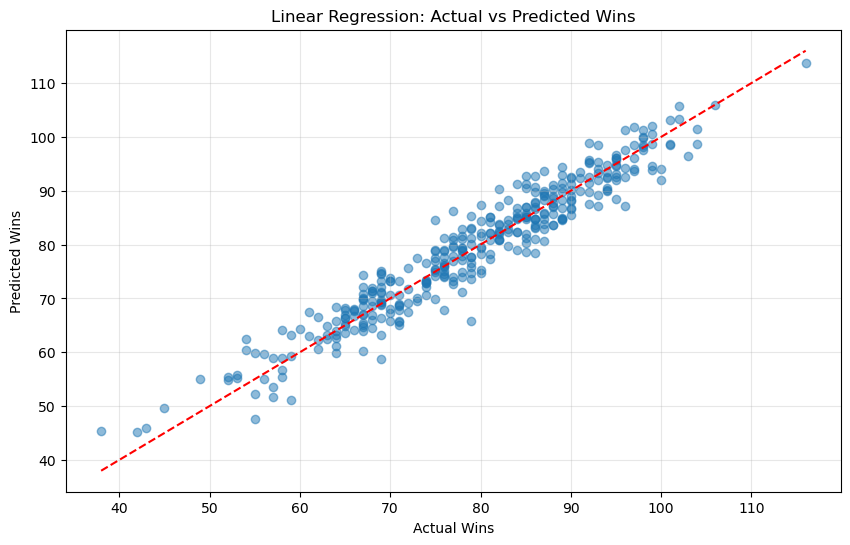

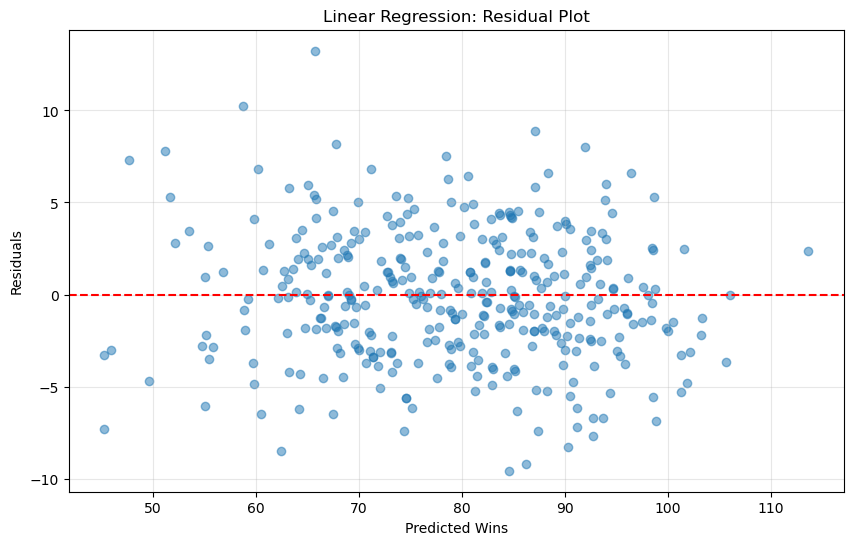

In [44]:
# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, lr_test_preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Wins')
plt.ylabel('Predicted Wins')
plt.title('Linear Regression: Actual vs Predicted Wins')
plt.grid(True, alpha=0.3)

# Add residual plot
plt.figure(figsize=(10, 6))
residuals = y_test - lr_test_preds
plt.scatter(lr_test_preds, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Wins')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()